# ResNet18 — Evaluation Only (No Training)
Kaydedilmiş modelleri yükleyip test seti üzerinde değerlendirme yapar.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

print('Imports OK')

Imports OK


In [2]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print('Device:', device)

Device: cpu


In [3]:
base_path = '../data/'
valid_dir = os.path.join(base_path, 'valid')
test_dir  = os.path.join(base_path, 'test')

valid_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=valid_test_transforms)

valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print('Test size:',  len(test_dataset))
print('Classes:',    test_dataset.classes)

Test size: 1070
Classes: ['0', '1']


In [4]:
def build_resnet():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model


def evaluate_model(model, loader, device, epoch_label, threshold=0.4):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f'\n--- ResNet18 {epoch_label} Test Results ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'ResNet18 {epoch_label} Confusion Matrix')
    os.makedirs('../outputs', exist_ok=True)
    tag = epoch_label.replace(' ', '_')
    plt.savefig(f'../outputs/resnet18_confusion_matrix_{tag}.png', bbox_inches='tight')
    plt.show()
    print(f'TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}')

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title(f'ResNet18 {epoch_label} ROC Curve')
    plt.legend(loc='lower right')
    plt.savefig(f'../outputs/resnet18_roc_curve_{tag}.png')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}


def get_val_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


print('Functions defined.')

Functions defined.


## 5 Epoch Model — Load & Evaluate

5 epoch model loaded.
Validation Accuracy (5ep): 91.21%

--- ResNet18 5 Epoch Test Results ---
Accuracy : 0.9318
Precision: 0.9639
Recall   : 0.8972
F1-Score : 0.9293
ROC-AUC  : 0.9862


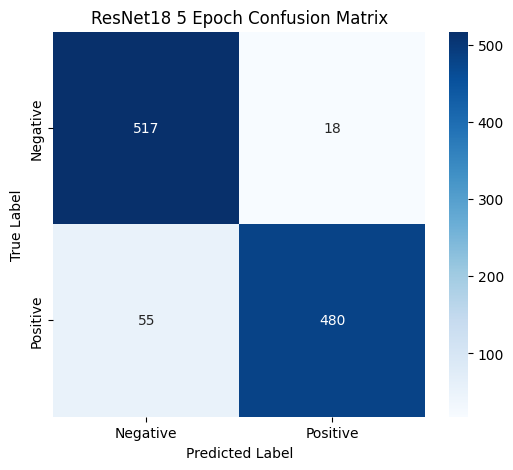

TN:517  FP:18  FN:55  TP:480


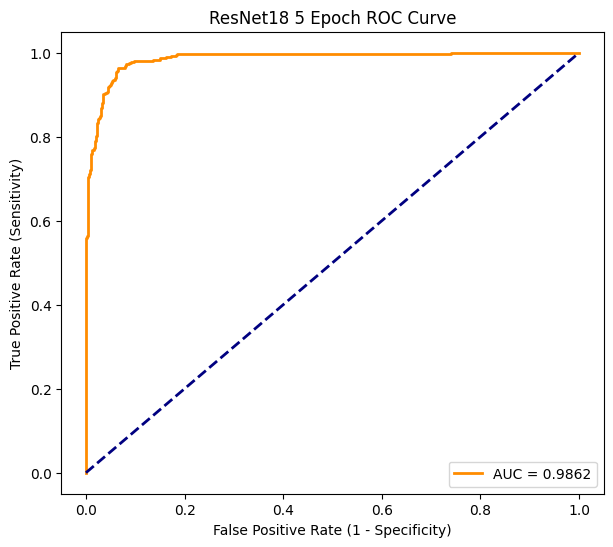

In [5]:
resnet_5ep = build_resnet()
resnet_5ep.load_state_dict(
    torch.load('../models/resnet18_chest_xray.pth', map_location=device)
)
resnet_5ep = resnet_5ep.to(device)
resnet_5ep.eval()
print('5 epoch model loaded.')

val_acc_5ep = get_val_acc(resnet_5ep, valid_loader, device)
print(f'Validation Accuracy (5ep): {val_acc_5ep:.2f}%')

metrics_5ep = evaluate_model(resnet_5ep, test_loader, device, '5 Epoch')

## 10 Epoch Model — Load & Evaluate

10 epoch model loaded.
Validation Accuracy (10ep): 94.02%

--- ResNet18 10 Epoch Test Results ---
Accuracy : 0.9533
Precision: 0.9533
Recall   : 0.9533
F1-Score : 0.9533
ROC-AUC  : 0.9908


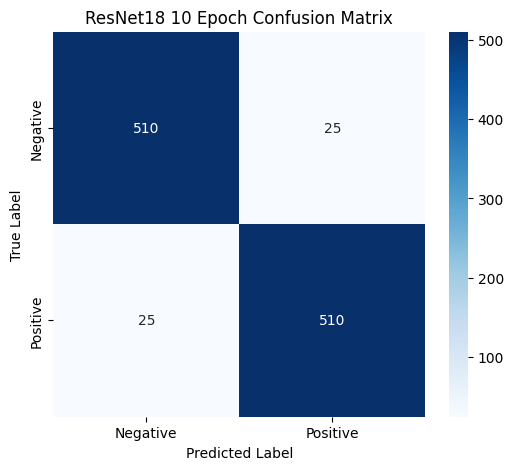

TN:510  FP:25  FN:25  TP:510


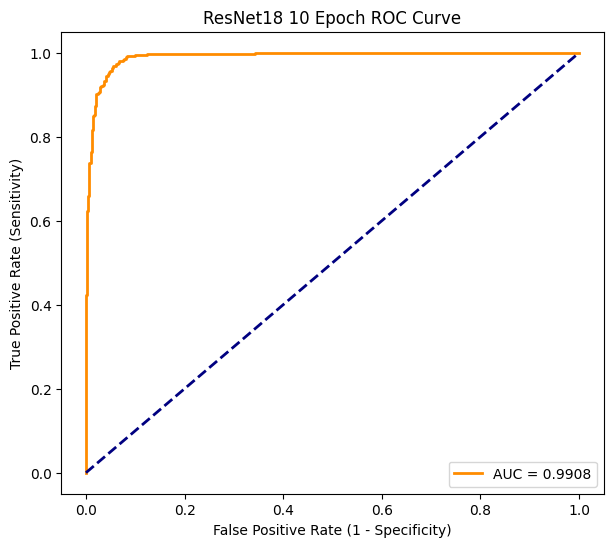

In [6]:
resnet_10ep = build_resnet()
resnet_10ep.load_state_dict(
    torch.load('../models/resnet18_chest_xray_10epoch.pth', map_location=device)
)
resnet_10ep = resnet_10ep.to(device)
resnet_10ep.eval()
print('10 epoch model loaded.')

val_acc_10ep = get_val_acc(resnet_10ep, valid_loader, device)
print(f'Validation Accuracy (10ep): {val_acc_10ep:.2f}%')

metrics_10ep = evaluate_model(resnet_10ep, test_loader, device, '10 Epoch')

Epoch  5 => Val Acc: 91.21%
Epoch 10 => Val Acc: 94.02%


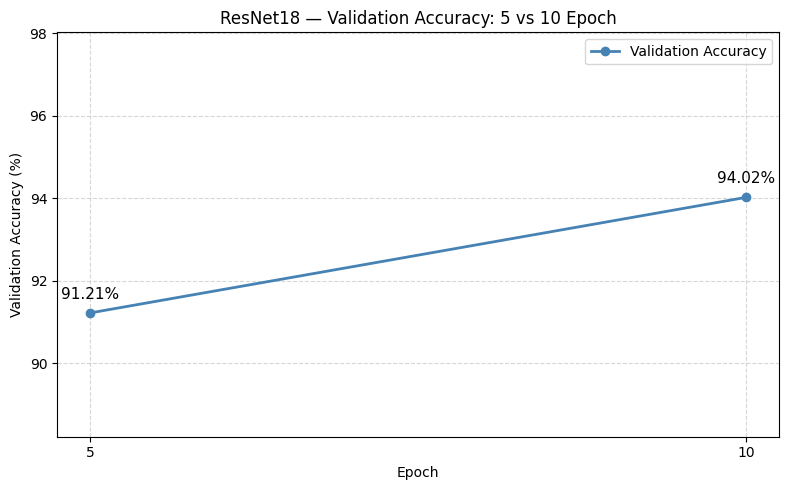

In [8]:
# ===== RESNET18 — 5 vs 10 EPOCH VAL ACCURACY GRAPH =====

import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

def build_model():
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, 2)
    return m

valid_loader_graph = DataLoader(
    datasets.ImageFolder('../data/valid', transform=transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])),
    batch_size=8, shuffle=False
)

def checkpoint_val_acc(path):
    model = build_model()
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in valid_loader_graph:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

checkpoints = [
    (5,  '../models/resnet18_chest_xray.pth'),
    (10, '../models/resnet18_chest_xray_10epoch.pth'),
]

epochs_x, val_accs = [], []
for ep, path in checkpoints:
    if os.path.exists(path):
        acc = checkpoint_val_acc(path)
        epochs_x.append(ep)
        val_accs.append(acc)
        print(f'Epoch {ep:2d} => Val Acc: {acc:.2f}%')
    else:
        print(f'WARNING: {path} bulunamadi.')

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, val_accs, marker='o', linewidth=2, color='steelblue', label='Validation Accuracy')
for x, y in zip(epochs_x, val_accs):
    plt.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
plt.title('ResNet18 — Validation Accuracy: 5 vs 10 Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_x)
plt.ylim(min(val_accs) - 3, max(val_accs) + 4)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/resnet18_val_accuracy_5vs10.png', bbox_inches='tight')
plt.show()

## Final Results DataFrame

In [7]:
os.makedirs('../outputs/model_results', exist_ok=True)

resnet_results_df = pd.DataFrame({
    'Model': ['ResNet18', 'ResNet18'],
    'Epoch': [5, 10],
    'Best Validation Accuracy':  [val_acc_5ep,                     val_acc_10ep],
    'Final Validation Accuracy': [val_acc_5ep,                     val_acc_10ep],
    'Test Accuracy': [metrics_5ep['accuracy'] * 100, metrics_10ep['accuracy'] * 100],
    'Precision':     [metrics_5ep['precision'],       metrics_10ep['precision']],
    'Recall':        [metrics_5ep['recall'],           metrics_10ep['recall']],
    'F1-Score':      [metrics_5ep['f1'],               metrics_10ep['f1']],
    'ROC-AUC':       [metrics_5ep['auc'],              metrics_10ep['auc']]
})

resnet_results_df.to_csv('../outputs/model_results/resnet18_5epoch_summary.csv',  index=False)
resnet_results_df.to_csv('../outputs/model_results/resnet18_10epoch_summary.csv', index=False)

resnet_results_df

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ResNet18,5,91.214953,91.214953,93.177570,0.963855,0.897196,0.929332,0.986193
1,ResNet18,10,94.018692,94.018692,95.327103,0.953271,0.953271,0.953271,0.990822
